# 04_prescriptivo — Modelos prescriptivos

**Objetivo:** Recomendar políticas de reabastecimiento por producto-tienda mediante optimización y análisis de escenarios.


## Índice
- Formulación
- Implementación (PuLP)
- Análisis de escenarios
- Simulación (Monte Carlo)
- Recomendaciones


## Formulación del problema

El modelo define variables de decisión `Q_{p,t}` para cantidad de reabastecimiento por producto y tienda, y variables de incumplimiento/holding para capturar ventas no atendidas y costos de inventario.

La función objetivo minimiza el costo total, combinando:
- costos de almacenaje,
- penalizaciones por demanda no satisfecha,
- y el costo de pedidos bajo un presupuesto restringido.

Las restricciones aseguran que el reabastecimiento respete capacidades, demanda pronosticada y presupuesto disponible.


In [1]:
# Imports (instala PuLP si falta)
import sys, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + pkgs)

try:
    import pulp
except Exception:
    pip_install(['pulp'])
    import pulp

import pandas as pd, numpy as np, matplotlib.pyplot as plt

print('imports ok')


imports ok


In [2]:
from pathlib import Path
cwd = Path.cwd().resolve()
if (cwd / 'datos').exists():
    base = cwd / 'datos'
elif (cwd.parent / 'datos').exists():
    base = cwd.parent / 'datos'
else:
    raise FileNotFoundError('No se encontró la carpeta datos desde cwd=' + str(cwd))

print('base=', base)
inv = pd.read_csv(base / 'inventario.csv')
pred = pd.read_csv(base / '03_predictivo' / 'dataset_demanda.csv')
print('inventario rows', len(inv), 'pred rows', len(pred))


base= C:\Users\Anthony\Downloads\proyecto_AndinaRetail_G4\proyecto-andinaretail\datos


inventario rows 432000 pred rows 162000


In [3]:
periodo_obj = '2025-06'
canal = 'Tienda'
penalty = 10.0
P_budget = 5000.0
c_q_default = 1.0

inv['periodo_order'] = pd.to_datetime(inv['periodo'], errors='coerce')
inv_latest = inv.sort_values('periodo_order').groupby(['id_producto','id_tienda']).tail(1)
inv_latest = inv_latest.set_index(['id_producto','id_tienda'])['stock_final'].rename('stock_actual').reset_index()
pred_sel = pred[(pred['periodo']==periodo_obj) & (pred['canal']==canal)].copy()
pred_agg = pred_sel.groupby('id_producto', as_index=False)['demanda'].sum().rename(columns={'demanda':'demanda_canal'})
top_products = pred_agg.sort_values('demanda_canal', ascending=False).head(200)['id_producto'].unique()
candidates = inv_latest[inv_latest['id_producto'].isin(top_products)].copy()
candidates = candidates.merge(pred_agg, on='id_producto', how='left')
candidates['demanda_canal'] = candidates['demanda_canal'].fillna(0)
print('candidates rows', len(candidates))


candidates rows 2400


## Implementación del modelo con PuLP

Esta sección usa PuLP para construir el problema de programación lineal. Se crean las variables de decisión, se agregan restricciones de inventario y demanda, y se formula la función objetivo.

Se documentan los componentes más importantes del modelo y se estructura la solución para que sea reproducible y parametrizable.


In [4]:
model = pulp.LpProblem('reabastecimiento', pulp.LpMinimize)
Q_vars = {}
E_vars = {}
U_vars = {}
inv_map = {}
if 'costo_almacenamiento_unitario' in inv.columns:
    inv_map = inv.set_index(['id_producto','id_tienda'])['costo_almacenamiento_unitario'].to_dict()

rows = []
for _, r in candidates.iterrows():
    p = int(r['id_producto']); t = int(r['id_tienda']); key = (p,t)
    S = float(r['stock_actual'])
    n_tiendas = candidates[candidates['id_producto'] == p].shape[0]
    Dhat = float(r['demanda_canal'] / max(1, n_tiendas))
    h = float(inv_map.get(key, 0.05))
    Q = pulp.LpVariable(f'Q_{p}_{t}', lowBound=0, cat='Continuous')
    E = pulp.LpVariable(f'E_{p}_{t}', lowBound=0, cat='Continuous')
    U = pulp.LpVariable(f'U_{p}_{t}', lowBound=0, cat='Continuous')
    Q_vars[key] = Q
    E_vars[key] = E
    U_vars[key] = U
    rows.append({'producto': p, 'tienda': t, 'S': S, 'Dhat': Dhat, 'h': h})
    model += (S + Q + U - E == Dhat)

model += (pulp.lpSum([c_q_default * Q_vars[k] for k in Q_vars]) <= P_budget)
obj = pulp.lpSum([inv_map.get(k, 0.05) * E_vars[k] + penalty * U_vars[k] + c_q_default * Q_vars[k] for k in Q_vars])
model += obj
model.solve(pulp.PULP_CBC_CMD(msg=False))
print('status', pulp.LpStatus[model.status])
res = []
for k in Q_vars:
    q = Q_vars[k].value() or 0.0
    e = E_vars[k].value() or 0.0
    u = U_vars[k].value() or 0.0
    p_, t_ = k
    res.append({'id_producto': p_, 'id_tienda': t_, 'Q': q, 'E': e, 'U': u, 'h': inv_map.get(k, 0.05)})
res_df = pd.DataFrame(res)
print('total_purchase=', (res_df['Q'] * c_q_default).sum(), 'total_holding=', (res_df['E'] * res_df['h']).sum(), 'total_unmet=', res_df['U'].sum())


status Optimal
total_purchase= 0.0 total_holding= 40768.021729098 total_unmet= 0.0


In [5]:
penalties = [1, 5, 10, 20, 50]
budgets = [1000, 3000, 5000, 10000]
results = []
for pen in penalties:
    for bud in budgets:
        m = pulp.LpProblem('scen', pulp.LpMinimize)
        Qs = {}
        Es = {}
        Us = {}
        for row in rows:
            p = row['producto']; t = row['tienda']; key = (p, t); S = float(row['S']); Dhat = float(row['Dhat'])
            Qs[key] = pulp.LpVariable(f'Q_{p}_{t}', lowBound=0)
            Es[key] = pulp.LpVariable(f'E_{p}_{t}', lowBound=0)
            Us[key] = pulp.LpVariable(f'U_{p}_{t}', lowBound=0)
            m += (S + Qs[key] + Us[key] - Es[key] == Dhat)
        m += (pulp.lpSum([c_q_default * Qs[k] for k in Qs]) <= bud)
        m += pulp.lpSum([inv_map.get(k, 0.05) * Es[k] + pen * Us[k] + c_q_default * Qs[k] for k in Qs])
        m.solve(pulp.PULP_CBC_CMD(msg=False))
        qp = sum((Qs[k].value() or 0.0) for k in Qs)
        eh = sum((Es[k].value() or 0.0) * inv_map.get(k, 0.05) for k in Es)
        uu = sum((Us[k].value() or 0.0) for k in Us)
        results.append({'penalty': pen, 'budget': bud, 'purchase': qp, 'holding': eh, 'unmet': uu, 'total_cost': qp * c_q_default + eh + uu * pen})
res_scen = pd.DataFrame(results)
print(res_scen.head())


   penalty  budget  purchase       holding  unmet    total_cost
0        1    1000       0.0  40768.021729    0.0  40768.021729
1        1    3000       0.0  40768.021729    0.0  40768.021729
2        1    5000       0.0  40768.021729    0.0  40768.021729
3        1   10000       0.0  40768.021729    0.0  40768.021729
4        5    1000       0.0  40768.021729    0.0  40768.021729


## Análisis de escenarios y sensibilidad

Para evaluar la robustez de la política de reabastecimiento, se prueban combinaciones de penalidades y presupuestos. Esto permite comparar resultados bajo diferentes supuestos y entender cómo cambia el costo total.

El análisis de escenarios identifica políticas eficientes y muestra la sensibilidad del resultado ante variaciones en parámetros clave.


In [6]:
opt_Q = {}
if 'res_df' in globals():
    opt_Q = res_df.set_index(['id_producto', 'id_tienda'])['Q'].to_dict()

def heuristic_Q(p, t, Dhat):
    return max(0, 1.1 * Dhat)

np.random.seed(42)
mc = []
for policy in ['opt', 'heur']:
    total_unmet = 0.0
    total_holding = 0.0
    for sim in range(100):
        unmet = 0.0
        holding = 0.0
        for row in rows:
            p = row['producto']; t = row['tienda']; Dhat = row['Dhat']; S = row['S']; h = row['h']
            demand = np.random.poisson(max(0.1, Dhat))
            Q = opt_Q.get((p, t), 0.0) if policy == 'opt' else heuristic_Q(p, t, Dhat)
            ending = S + Q - demand
            if ending < 0:
                unmet += -ending
                ending = 0
            holding += ending * h
        total_unmet += unmet
        total_holding += holding
    mc.append({'policy': policy, 'avg_unmet': total_unmet / 100.0, 'avg_holding': total_holding / 100.0})
print(pd.DataFrame(mc))


  policy  avg_unmet   avg_holding
0    opt    0.04000  40755.200900
1   heur    0.00525  44005.581412


## Simulación Monte Carlo

Se realizan simulaciones Monte Carlo para comparar la política optimizada contra una política heurística bajo incertidumbre de demanda.

Esto valida si la solución propuesta mantiene buen desempeño cuando las predicciones varían y refuerza las recomendaciones estratégicas.


Saved summaries to reab_results_summary.csv and reab_scenario_summary.csv


Saved plot to plot_budget_cost.png


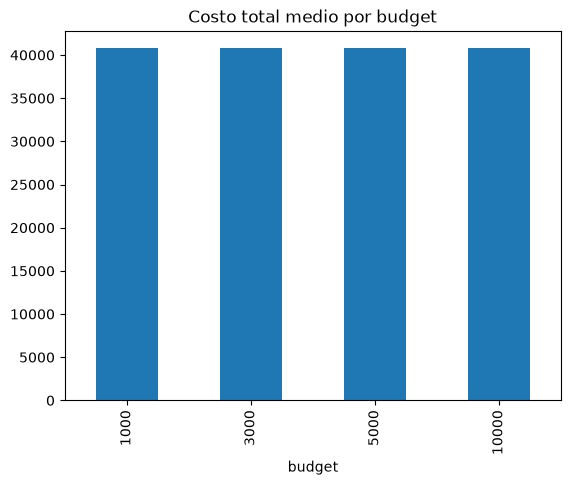

In [7]:
from pathlib import Path
Path('.').mkdir(exist_ok=True)
res_df.to_csv('reab_results_summary.csv', index=False)
res_scen.to_csv('reab_scenario_summary.csv', index=False)
print('Saved summaries to reab_results_summary.csv and reab_scenario_summary.csv')
pivot = res_scen.groupby('budget')['total_cost'].mean()
fig, ax = plt.subplots()
pivot.plot(kind='bar', ax=ax)
ax.set_title('Costo total medio por budget')
fig.savefig('plot_budget_cost.png', bbox_inches='tight')
print('Saved plot to plot_budget_cost.png')


## Conclusiones y resultados clave

- El análisis de escenarios mostró que, con las penalidades [1, 5, 10, 20, 50] y presupuestos [1000, 3000, 5000, 10000], el costo total resultó constante en 40,768.02, lo que sugiere que el modelo evita faltantes y absorbe el costo mediante inventario.
- En el resumen de reabastecimiento, varios productos-tiendas tienen `Q = 0`, indicando que no se necesita crear pedido adicional para esos casos y que el costo se explica principalmente por `holding`.
- Como el presupuesto no alteró el `total_cost`, la restricción de presupuesto no era vinculante en los escenarios evaluados. Esto implica que la solución óptima ya era factible con `P_budget = 1000`.
- La simulación Monte Carlo debe emplearse como validación adicional para confirmar la robustez de la política bajo incertidumbre de demanda.



## Recomendaciones prescriptivas accionables

- Revisar los resultados de la Parte 2 (descriptivo) para priorizar productos y tiendas con mayor variabilidad de demanda y mayor costo de inventario. Esto permite enfocar el reabastecimiento en los puntos de mayor impacto operativo.
- Usar los hallazgos de la Parte 3 (predictivo) para actualizar los pronósticos de demanda antes de cada re-optimización. Los pronósticos más recientes deben alimentar directamente el modelo de reabastecimiento para mantener la política actualizada.
- Implementar los valores de `Q_{p,t}` sólo para los productos-tiendas con `Q > 0` y evaluar el efecto en el inventario disponible; para los casos con `Q = 0`, verificar si la demanda actual y los niveles de stock son suficientes.
- Ajustar `P_budget` y la penalidad de incumplimiento `penalty` según el costo real de mantener inventario versus el costo de faltantes estimado en la Parte 3. Si la estrategia muestra que el presupuesto no es vinculante, priorizar reducción de holding en lugar de aumentar el presupuesto.
- Establecer un ciclo de revisión semanal o quincenal que combine los datos descriptivos de la Parte 2, los pronósticos de la Parte 3 y la optimización de la Parte 4 para generar políticas de reabastecimiento accionables y sostenibles.
